In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [2]:
path_to_dataset = "/home/jwalitnpanchal/college_work/sem10/ML_AI/linear_regression/Student_Performance.csv"
student_dataset = pd.read_csv(path_to_dataset)
print(student_dataset,"\n",student_dataset.columns)

      Hours Studied  ...  Performance Index
0                 7  ...               91.0
1                 4  ...               65.0
2                 8  ...               45.0
3                 5  ...               36.0
4                 7  ...               66.0
...             ...  ...                ...
9995              1  ...               23.0
9996              7  ...               58.0
9997              6  ...               74.0
9998              9  ...               95.0
9999              7  ...               64.0

[10000 rows x 6 columns] 
 Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


In [10]:
student_dataset=student_dataset.drop(columns="Extracurricular Activities")

In [13]:
student_dataset

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0
...,...,...,...,...,...
9995,1,49,4,2,23.0
9996,7,64,8,5,58.0
9997,6,83,8,5,74.0
9998,9,97,7,0,95.0


In [15]:
response = student_dataset["Performance Index"]
predictors = student_dataset.drop(columns="Performance Index")

In [17]:
predictors = sm.add_constant(predictors)
print(predictors)

      const  Hours Studied  ...  Sleep Hours  Sample Question Papers Practiced
0       1.0              7  ...            9                                 1
1       1.0              4  ...            4                                 2
2       1.0              8  ...            7                                 2
3       1.0              5  ...            5                                 2
4       1.0              7  ...            8                                 5
...     ...            ...  ...          ...                               ...
9995    1.0              1  ...            4                                 2
9996    1.0              7  ...            8                                 5
9997    1.0              6  ...            8                                 5
9998    1.0              9  ...            7                                 0
9999    1.0              7  ...            8                                 1

[10000 rows x 5 columns]


In [34]:
# doing OLS using sm for response and the predictors and then calculating the predicted response y^cap
mlr_model = sm.OLS(response,predictors)
results = mlr_model.fit()
#print(results.params.iloc[0])
predicted_response = np.asarray(predictors)@np.asarray(results.params)
print(predicted_response)

[91.53224386 63.46956945 44.73619556 ... 72.68593823 94.05407095
 65.59132241]


In [20]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 2.147e+05
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:29:25   Log-Likelihood:                -21418.
No. Observations:               10000   AIC:                         4.285e+04
Df Residuals:                    9995   BIC:                         4.288e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

# Calculation of F statistic and p-value#

In [37]:
num_obs = np.asarray(student_dataset["Hours Studied"]).shape[0]
kp1 = len(student_dataset.columns)
num_predictors = kp1-1
print(num_obs, kp1, num_predictors, )

10000 5 4


In [28]:
def SST_finder(y:np.ndarray):
    y_mean = np.mean(y)
    sst = np.sum(np.square(y-y_mean))
    return sst
sst_student = SST_finder(response)
print(sst_student)

3690854.6496


In [35]:
def SSR_finder(ycap:np.ndarray, y:np.ndarray):
    y_mean = np.mean(y)
    ssr = np.sum(np.square(ycap-y_mean))
    return (ssr)
ssr_student = SSR_finder(predicted_response, response)
print(ssr_student)

3648402.888513378


In [36]:
def SSE_finder(y:np.ndarray, ycap:np.ndarray):
    return np.sum(np.square(y-ycap))
sse_student = SSE_finder(response, predicted_response)
print(sse_student)

42451.76108662532


In [61]:
# function for caluclating the F-statistic
def FStat_finder(y, ycap, dfn, n):
    msr = SSR_finder(ycap=ycap, y=y)/dfn
    mse = SSE_finder(y=y, ycap=ycap)/(n-dfn-1)
    return msr/mse
f_stat_student = FStat_finder(response, predicted_response, num_predictors, n=num_obs)
print(f" f-statistic is: {f_stat_student:.5e}")

 f-statistic is: 2.14748e+05


In [62]:
from scipy.stats import f

df1 = num_predictors
df2 = num_obs - num_predictors - 1

x_space = np.linspace(0,10,100)
f_dis = f.pdf(x_space, df1, df2)
print(df1, df2)

4 9995


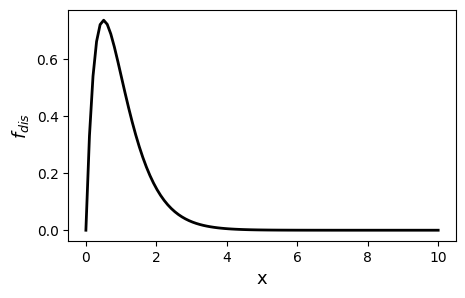

In [66]:
import matplotlib.pyplot as plt
figsize = (5,3)
plt.figure(1,figsize=figsize)
plt.plot(x_space, f_dis, color="black",lw=2)
plt.xlabel(r"x", fontsize=13)
plt.ylabel(r"$f_{dis}$", fontsize=13)
plt.show()

To decide the p-value of the calculated $f_{stat}$ we need to find the critical f-value from the below table
<p align="center">
<img src="f_dis_table.png" alt="Lorenz attractor" width="400">
</p>

From the table $f_{crit}=3.72$

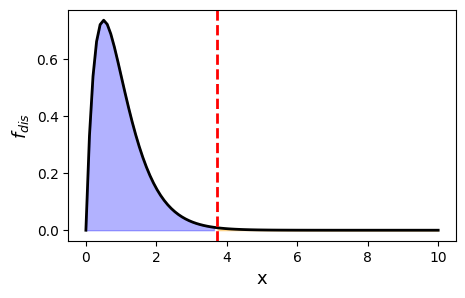

In [67]:
import matplotlib.pyplot as plt
import numpy as np
figsize = (5,3)
x0 = 3.72
plt.figure(1, figsize=figsize)
# main curve
plt.plot(x_space, f_dis, color='black',lw=2)
# vertical line
plt.axvline(x=x0, color='red', linestyle='--',lw=2)
# regions
left = x_space <= x0
right = x_space >= x0
# shading
plt.fill_between(x_space[left], f_dis[left], color='blue', alpha=0.3)
plt.fill_between(x_space[right], f_dis[right], color='orange', alpha=0.3)

plt.xlabel(r"x", fontsize=13)
plt.ylabel(r"$f_{dis}$", fontsize=13)
plt.show()